# Image appraisal in geophysics
Image appraisal in geophysics refers to the evaluation of the quality, reliability, and accuracy of inverse models derived from geophysical data. It involves assessing factors such as resolution, sensitivity, and model parameter uncertainties to ensure the validity of subsurface interpretations. 

This tutorial should give an overview of basic image appraisal methods in geoeletrical monitoring that could provide helpful tools for your future synthetic studies as well as field applications.

### Content of this tutorial:

**1) Returning and plotting sensitivities of single configurations**

**2) Manually assessing the coverage of a dataset**

**3) Calculating the model resolution matrix R**

**4) Assessing the Depth of Investigation** (Oldenburg and Li, 1999)


We will start on a synthetic 2D geometry and then switch to the salinity data for more "hands-on" experience with actual field data.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert

## 1) Assessing the sensitivity of single configurations

We will start this tutorial by **assessing sensitivities of single four-point arrays**.  

You can either use a dataset of your choice or utilize the example dataset provided in the GIT repo. As input for this exercise, we only need an inverse model + corresponding mesh. Please start by importing your dataset or inverse model + mesh:

##### **Import your data here:**

In [2]:
mesh = pg.load("mesh_example1.bms")

data = pg.load('bulk_data.dat')
data['err'] = ert.estimateError(
    data,
    relativeError=0.04,
    absoluteUError=5e-5)

mgr = ert.ERTManager(data)
inv = mgr.invert(mesh=mesh, lam=25, verbose=True)

17/02/25 - 09:59:07 - pyGIMLi - INFO - Found 3589 regions.
17/02/25 - 09:59:07 - pyGIMLi - INFO - Region with smallest marker (0) set to background
17/02/25 - 09:59:07 - pyGIMLi - INFO - Creating forward mesh from region infos.
17/02/25 - 09:59:07 - pyGIMLi - INFO - Creating refined mesh (P2) to solve forward task.
17/02/25 - 09:59:07 - pyGIMLi - INFO - Use median(data values)=3.06844394897819
17/02/25 - 09:59:07 - pyGIMLi - INFO - Created startmodel from forward operator: 3588 [3.06844394897819,...,3.06844394897819]
17/02/25 - 09:59:07 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001A6AFD84130>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x000001A6AFD84220>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x000001A6AFD841D0>
min/max (data): 1.27/960
min/max (error): 4%/34.41%
min/max (start model): 3.07/3.07
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
inv.iter 2 ... chi² = 25.96 (dPhi = 73.56%) lam: 25
--------------------------------------------------------------------------------
inv.iter 3 ... chi² = 4.9 (dPhi = 48.21%) lam: 25.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² = 3.25 (dPhi = 5.57%) lam: 25.0
--------------------------------------------------------------------------------
inv.iter 5 ... chi² = 2.95 (dPhi = 0.67%) lam: 25.0
###########################################################

Based on the provided inversion result, we now want to plot the sensitivity of single four-point arrays, as seen in [this example on the pyGIMLi website](https://www.pygimli.org/_examples_auto/3_ert/plot_05_ert_4_point_sensitivities.html).

#### 1a) Start by getting the Jacobian matrix (and visualize its dimensions). After doing so, pick a single configuration and plot its normalized, logarithmic sensitivity distribution. Optionally, mark the current and potential electrodes used for the particular configuration in question.

##### **Result:**

Text(0, 0.5, 'y (m)')

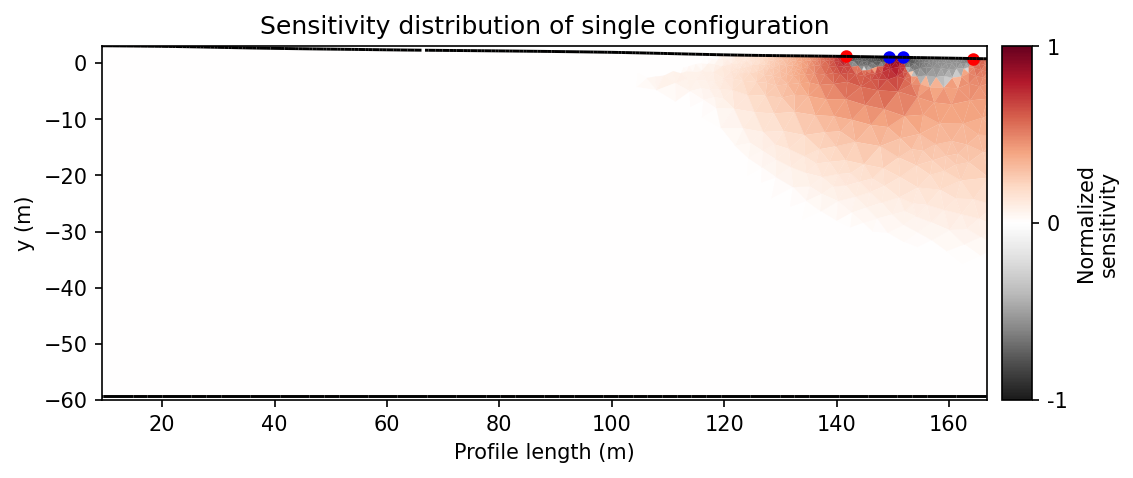

In [4]:
meshPD = pg.Mesh(mgr.paraDomain)
jaco = mgr.fop.jacobian()

# Optional:
def get_elecs(i):
    coords = {}
    for elec in "abmn":
        elec_id = int(data(elec)[i])
        elec_pos = data.sensorPosition(elec_id)
        coords[elec] = elec_pos.x(), elec_pos.z()
    return coords

def plotABMN(ax, i):
    """ Visualize four-point configuration on given axes. """
    coords = get_elecs(i)
    for elec in coords:
        x, z = coords[elec]
        if elec in "ab":
            color = "red"
        else:
            color = "blue"

        
        ax.plot(x, z, marker=".", color=color, ms=10)
        ax.plot(coords["a"][0],)

# Normalized sensitivity:
def normSens(ax, i):
    #get_elecs(i)
    plotABMN(ax, i)
    normsens = pg.utils.logDropTol(jaco[i]/meshPD.cellSizes(), 8e-6)
    normsens /= np.max(normsens)
    pg.show(meshPD, normsens, cMap="RdGy_r", ax=ax, orientation="vertical",
            label="Normalized\nsensitivity", nLevs=3, cMin=-1, cMax=1)
    ax.set_ylim([-60,3])
    ax.set_xlim([data.sensorPositions()[0][0],data.sensorPositions()[-1][0]])

fig, ax = plt.subplots(1,1, figsize=(8,5), dpi=150)
sens1 = normSens(ax, 2)
ax.set_title("Sensitivity distribution of single configuration")
ax.set_xlabel("Profile length (m)")
ax.set_ylabel("y (m)")


In [5]:
rows = jaco.rows()
cols = jaco.cols()
print(f"Rows: {rows}, Columns: {cols}")

Rows: 989, Columns: 3588


#### 1b) Based on the already implemented code, get the four point array with the highest and lowest geometric factor K and plot its normalized sensitivity distribution on the model domain.

##### **Result:**

Text(0, 0.5, 'y (m)')

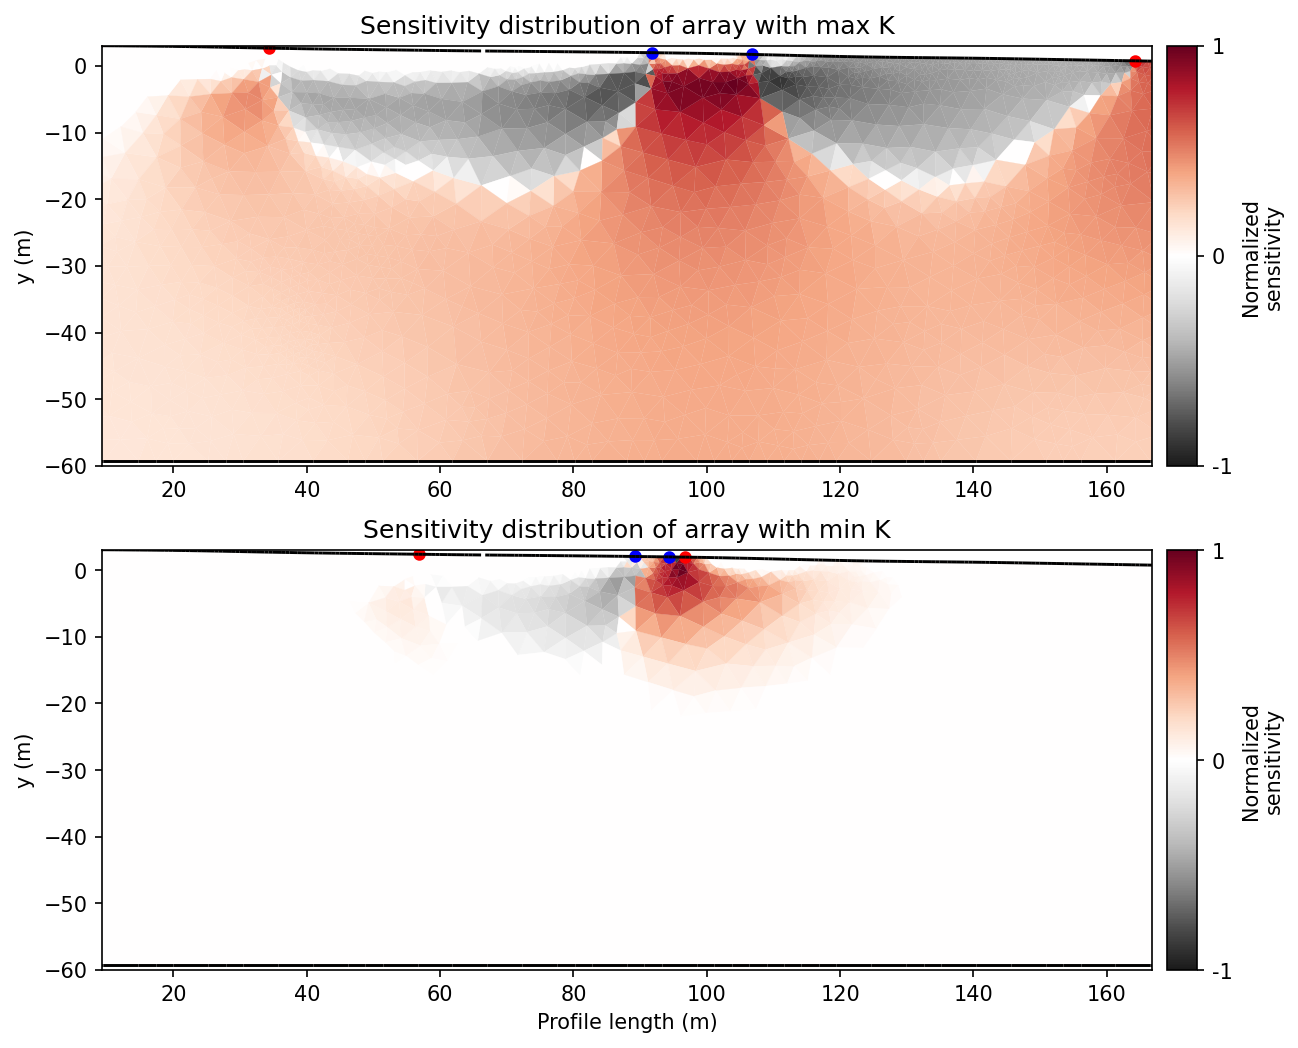

In [7]:
def get_extreme_sens(jaco):
    # Sum up all columns
    # Get the index of the column with the maximum value
    max_val = np.argmax(data["k"])
    min_val = np.argmin(data["k"])
    return min_val, max_val

min_k, max_k = get_extreme_sens(jaco)

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(12,8), dpi=150)
normSens(ax1, max_k)
ax1.set_title("Sensitivity distribution of array with max K")
ax1.set_ylabel("y (m)")
normSens(ax2, min_k)
ax2.set_title("Sensitivity distribution of array with min K")
ax2.set_xlabel("Profile length (m)")
ax2.set_ylabel("y (m)")

## 2) Displaying the coverage of a dataset

After introducing the sensitivity of single four-point configurations, we now want to take a look at another quality assessment parameter often used in geoelectrical imaging - the coverage. Coverage is defined as the **spatial distribution of the sensitivity of all measurements across the model space**. It indicates which regions are well covered and which areas lack data influence, thereby **helping to evaluate model reliability**.

#### 2a) Based on the previous results, calculate the coverage for the given example dataset using pyGIMLi's `coverage()` method of the ERTManager.

##### **Result:**

Text(0, 0.5, 'y (m)')

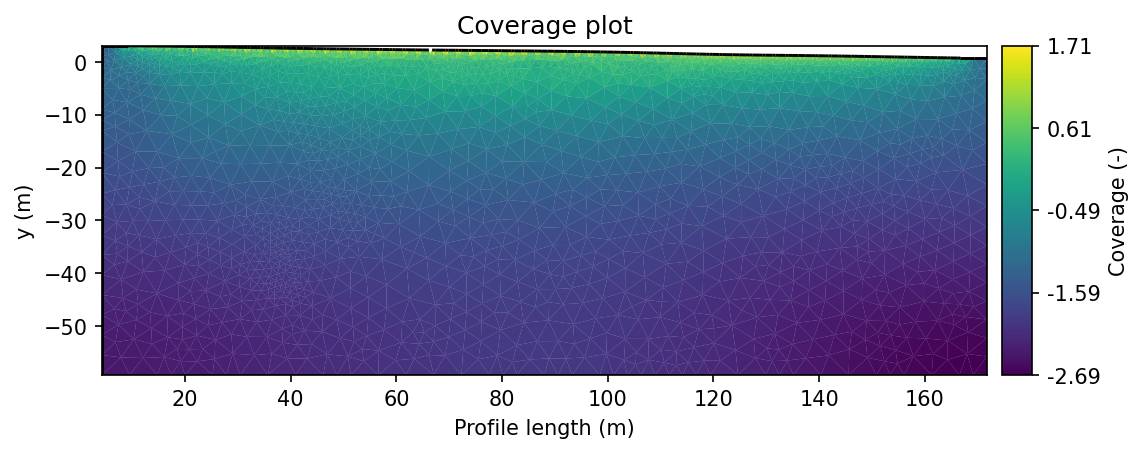

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8,5), dpi=150)

pg.show(meshPD, mgr.coverage(), ax=ax, orientation="vertical", label="Coverage (-)")
ax.set_title("Coverage plot")
ax.set_xlabel("Profile length (m)")
ax.set_ylabel("y (m)")

This plot nicely visualizes the depth dependency of the coverage in the model space. Going one step further, we can make use of the coverage to cut off those parts of the inverse model that correspond with areas of low coverage.

#### 2b) Define a function that masks the inverse model based on a given quality evaluation parameter. The function should allow to manually change the cutoff value. Utilize the coverage as input and plot the inversion result with the defined masking function.
##### _Hint: Use the variable coverage within the `mgr.showResult()` method to manually adjust the cutoff in the plot_.

##### **Result:**

Text(0, 0.5, 'y (m)')

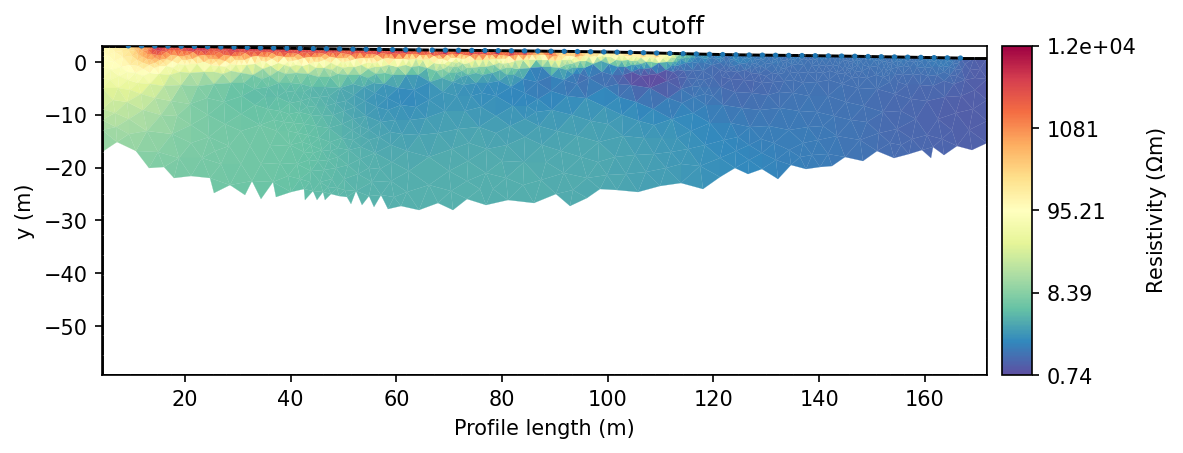

In [9]:
def quality_cutoff(mesh, eval_parameter, cutoff=0.6):
    opacity = np.ones(mesh.cellCount())
    opacity[eval_parameter < cutoff] = 0
    return opacity


mask = quality_cutoff(meshPD, mgr.coverage(), cutoff=-1.5)


fig, ax = plt.subplots(1,1, figsize=(8,5), dpi=150)
mgr.showResult(ax=ax, coverage=mask, orientation = "vertical")
ax.set_title("Inverse model with cutoff")
ax.set_xlabel("Profile length (m)")
ax.set_ylabel("y (m)")

This is a great and versatile tool to visually appraise the quality of an inverse model and, since any model space evaluation parameter can be inserted, it can be utilized for any parameter of choice!

Next up, we want to take a look into the evaluation of the image quality at a specific location with depth. Let's say, you want to get an evaluation of the image quality at a specific point along your survey to consider whether additional measurements would be helpful. By using pyGIMLi's interpolation function, we can build a tool that enables exactly that! 

#### 2c) Starting with the code snipped below, build a tool to assess the coverage changes with depth at a specific x-coordinate along the profile. _Hint: Use pyGIMLi's interpolate function!._

##### **Result:**

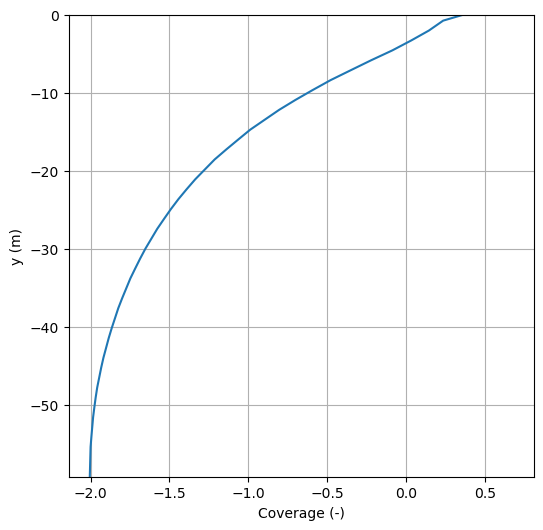

In [10]:
y = np.linspace(meshPD.ymax(), meshPD.ymin())
x = np.ones_like(y)*100

covs = pg.interpolate(srcMesh=meshPD, inVec=mgr.coverage(), x=x, y=y)

fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.plot(covs, y)
#ax.set_xlabel(f"Coverage at x = {x_in}")
ax.set_ylabel("y (m)")
ax.set_ylim(meshPD.ymin(),0)
ax.set_xlabel("Coverage (-)")
ax.grid(True)

## Takeaway messages
- We visualized the **sensitivities of single four point arrays** on the model space and underlined **differences in the distribution** based on the electrode and dipole spacing. This helps to get a feeling of which configurations provide information on which part of the model space. 
---
- We introduced the coverage as tool to assess the  **spatial distribution of the sensitivity of all measurements across the model space**, which allows to **objectively evaluate the reliability** in different parts of the model.
---
- We build a tool that allows us to **cut out areas** from the result plot that hold **low coverage**. However, this **tool is method-independent** and can therefore also be utilized with other quality evaluation parameters, such as the Depth of Investigation (DOI) and the model resolution. 
---
- We constructed a tool that allows us to assess the quality in a 1D column anywhere on the model. This way, we selectively evaluate the model quality for a specific region on the model space. 

---
## **Advanced section**
---

We presented powerful tools to assess the quality of inversion results, both locally as well as on the whole model space. However, the coverage and sensitivity provide only limited capacities as they do not consider regularization and linear (in)dependencies of different measurements.

For this purpose, we introduce another tool for the appraisal of geoelectrical inversion results - the **Depth of Investigation (DOI)** (from Oldenburg, D. W., & Li, Y. (1999). Estimating depth of investigation in DC resistivity and IP surveys. GEOPHYSICS. Society of Exploration Geophysicists. https://doi.org/10.1190/1.1444545).

DOI generally refers to the depth of the model space, **"below which surface data are insensitive to the value of the physical property"**, in our case to the electrical resistivity. Thus, the **interpretation of features below this depth should be handled with care**, since they might not be geologically feasible.

If we consider two inversion results that are carried out with **two different, homogeneous reference models** (e.g., two homogeneous reference models with $\rho (m_{1,r}) = $ 100 $\Omega m$ and b) $\rho (m_{1,r})$ = 500 $\Omega m$) and their inverse models $m_1$ and $m_2$, the DOI is computed by:
$$
R(x, z)=\frac{m_{1}(x, z)-m_{2}(x, z)}{m_{1 r}-m_{2 r}}
$$

In theory, the quality assessment parameter **R will approach 0** in regions of the model, where the **data constrain the model**, which means that the inversion does not significantly depend on the defined reference model. Thus, the inverse model provides **reliable information in those model areas**. Vice versa, if the inversion result shows values similar to the reference model, the credibility of the corresponding model regions should be low. 

Thus, the DOI provides a valuable tool to **assess the credibility of the inversion result** over the whole model domain.

#### a) Define a function to compute the DOI (Oldenburg and Li, 1999) for the previous inversion result. Use the following code snippet to set the reference models:

In [18]:
# Definition of reference models for DOI computation:

def run_inv(referencemodel):
    # Set reference model as startmodel
    mgr.inv.inv.setModel(referencemodel)

    # Set reference model
    rm = mgr.inv.fop.regionManager()
    rm.setConstraintType(10) # 0 = reference model, 1 = first-order smoothing (default), 10 = both
    rm.fillConstraints(mgr.inv.fop.constraints())
    mgr.inv.inv.setReferenceModel(referencemodel)
    model = mgr.inv.inv.run()
    return model

##### **Result:**

In [19]:
def compute_DOI(ref1, ref2):
    m1 = run_inv(ref1)
    m2 = run_inv(ref2)

    R = (m1 - m2) / (m1r - m2r)
    return R


m1r = np.ones(mgr.paraDomain.cellCount()) * 100
m2r = np.ones(mgr.paraDomain.cellCount()) * 500

DOI = compute_DOI(m1r, m2r)

Text(0, 0.5, 'y (m)')

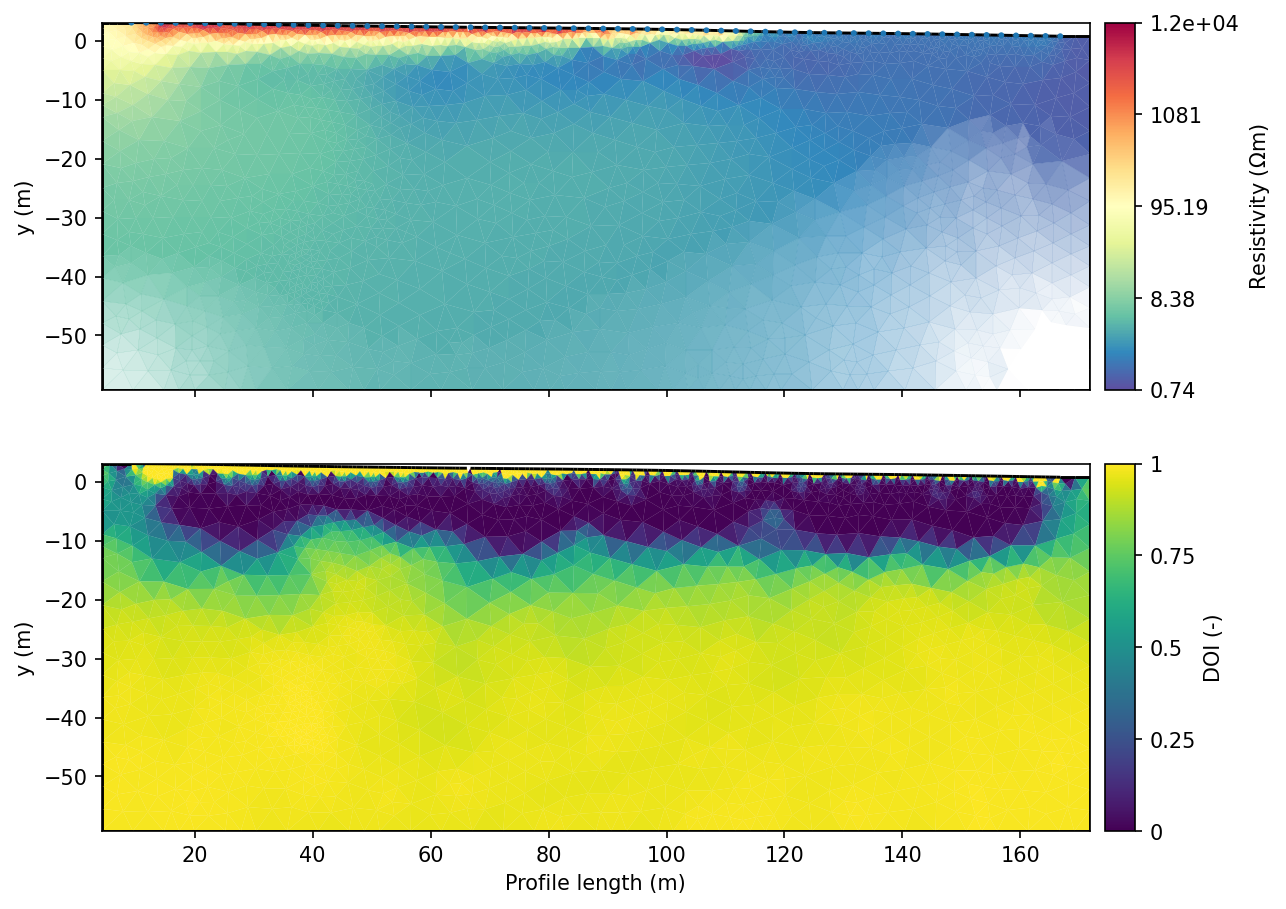

In [25]:
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(10,7), dpi=150, sharex=True)

mgr.showResult(ax=ax1, orientation="vertical")
#ax1.set_xlabel("Profile length")
ax1.set_ylabel("y (m)")
pg.show(meshPD, DOI, ax=ax2, cMin=0, cMax=1, orientation="vertical", label="DOI (-)")
ax2.set_xlabel("Profile length (m)")
ax2.set_ylabel("y (m)")

#### b) Use the previously defined cutoff function to plot the computed DOI value. Do you have to change something in the function?

##### **Result:**

Text(0, 0.5, 'y (m)')

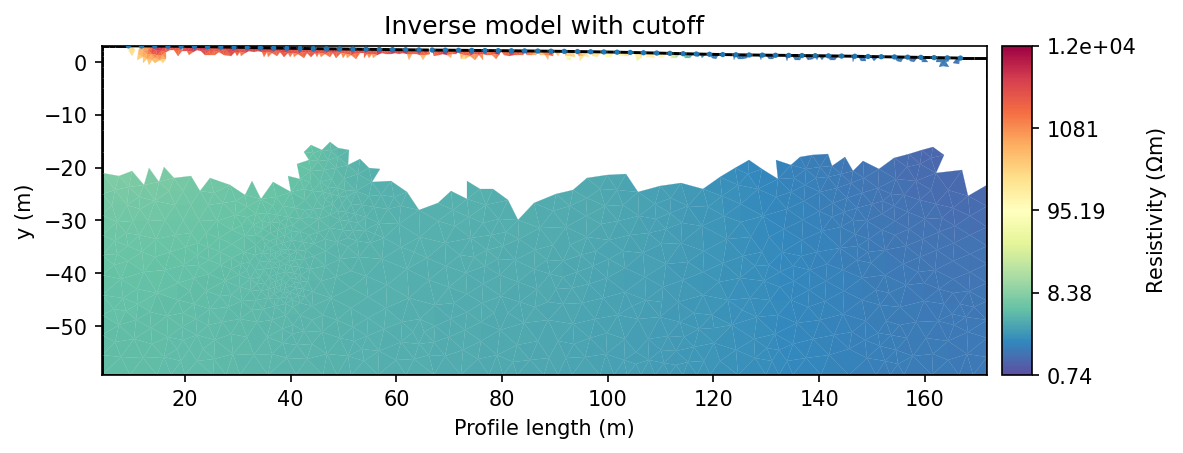

In [26]:
opacity = quality_cutoff(meshPD, DOI, 0.9)

fig, ax = plt.subplots(1,1, figsize=(8,5), dpi=150)
mgr.showResult(ax=ax, coverage=opacity, orientation = "vertical")
ax.set_title("Inverse model with cutoff")
ax.set_xlabel("Profile length (m)")
ax.set_ylabel("y (m)")

Since higher values in the DOI mark regions of lower credibility, everything below the threshold has to be plotted. However, the defined function above plots values above a given threshold. The following lines of code solve the problem:

##### **Result:**

Text(0, 0.5, 'y (m)')

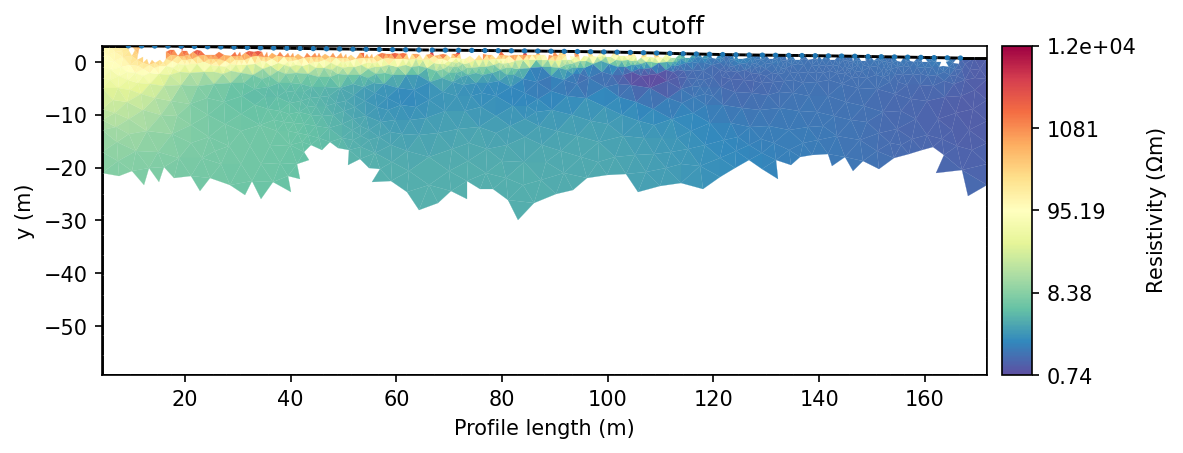

In [27]:
opacity = np.ones(mgr.paraDomain.cellCount())
opacity[DOI > 0.9] = 0
fig, ax = plt.subplots(1,1, figsize=(8,5), dpi=150)
mgr.showResult(ax=ax, coverage=opacity, orientation = "vertical")
ax.set_title("Inverse model with cutoff")
ax.set_xlabel("Profile length (m)")
ax.set_ylabel("y (m)")